# Learning Curves for Ames Housing Dataset

## Introduction

Learning curves are a diagnostic tool that help us understand how model performance changes as we vary the amount of training data. They provide insights into:

1. Whether adding more training data would improve model performance
2. If our model is suffering from high variance (overfitting) or high bias (underfitting)
3. The minimum amount of data needed to achieve acceptable performance

In this notebook, we'll analyze learning curves for our Ames housing price prediction models to better understand their behavior and identify potential improvements.

In [1]:
# Load our preprocessed data
try:
    # Try to use IPython magic if in notebook environment
    get_ipython().run_line_magic('run', 'src/preprocessing.py')
except (NameError, AttributeError):
    # If not in notebook environment, import directly
    import sys
    import os
    sys.path.append(os.path.join(os.path.dirname(__file__), 'src'))
    # Import specific variables from preprocessing
    from preprocessing import (
        dataset_1, dataset_2, dataset_3, dataset_4,
        target_1, target_2
    )

Remaining null values by column:
Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


/Users/joshuacook/working/linalg/data/linalg/lessons/case-study-05-ames/src/preprocessing.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_df.LotFrontage.fillna(housing_df.LotFrontage.mean(), inplace=True)
/Users/joshuacook/working/linalg/data/linalg/lessons/case-study-05-ames/src/preprocessing.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from tqdm import tqdm 
from time import time

## Dataset Overview

Let's first check the dimensions of our preprocessed datasets:

In [3]:
print("Dataset dimensions:")
print(f"Dataset 1: {dataset_1.shape}")
print(f"Dataset 2: {dataset_2.shape}")
print(f"Dataset 3: {dataset_3.shape}")
print(f"Dataset 4: {dataset_4.shape}")

Dataset dimensions:
Dataset 1: (1460, 381)
Dataset 2: (1460, 389)
Dataset 3: (1453, 381)
Dataset 4: (1453, 389)


### Dataset Descriptions

We have four different datasets, each representing different preprocessing approaches:

#### Dataset 1 - Standard Scaled Data Set

- Log Transformed, Standard Scaled Numerical Features (`numeric_log_std_sc_out_rem_df`)
- Complete One-hot Encoded Categorical Features (`categorical_encoded_df`)

#### Dataset 2 - Standard Scaled, PCA Augmented Data Set

- Log Transformed, Standard Scaled Numerical Features (`numeric_log_std_sc_out_rem_df`)
- Complete One-hot Encoded Categorical Features (`categorical_encoded_df`)
- PCA-transformed Numeric Data (`numeric_log_std_sc_out_rem_pca_df`)

#### Dataset 3 - Gelman Scaled Data Set

- Log Transformed, Gelman Scaled Numerical Features (`numeric_log_gel_sc_df`)
- One-hot Encoded Categorical Features with Significant Variance, Centered (`categorical_encoded_features_significant_variance_centered`)
- One-hot Encoded Categorical Features with Insignificant Variance (`categorical_encoded_features_insignificant_variance`)

#### Dataset 4 - Gelman Scaled, PCA Augmented Data Set

- Log Transformed, Gelman Scaled Numerical Features (`numeric_log_gel_sc_df`)
- One-hot Encoded Categorical Features with Significant Variance, Centered (`categorical_encoded_features_significant_variance_centered`)
- One-hot Encoded Categorical Features with Insignificant Variance (`categorical_encoded_features_insignificant_variance`)
- PCA-transformed Numeric and Significant Categorical (`numeric_gelman_categorical_significant_pca`)

## Benchmark Model Performance

Before analyzing learning curves, let's establish a baseline using our naive benchmark model that predicts the mean sale price for all houses.

In [4]:
# Calculate naive benchmark model performance
mean_sale_price = target_1.mean()
naive_guess = np.ones(len(target_1)) * mean_sale_price

# Calculate performance metrics
naive_r2 = r2_score(target_1, naive_guess)
naive_rmse = np.sqrt(mean_squared_error(target_1, naive_guess))
naive_mae = mean_absolute_error(target_1, naive_guess)

print("Naive Benchmark Model Performance:")
print(f"R² Score: {naive_r2:.4f}")
print(f"RMSE: ${naive_rmse:.2f}")
print(f"MAE: ${naive_mae:.2f}")

Naive Benchmark Model Performance:
R² Score: 0.0000
RMSE: $79415.29
MAE: $57434.77


## Learning Curve Analysis Functions

We'll define functions to help us analyze how model performance changes with training set size:

In [5]:
def sample_training_set(X_train, y_train, n_pcnt):
    """
    Sample a percentage of the training set
    
    Parameters:
    -----------
    X_train : DataFrame
        Training features
    y_train : Series
        Training target
    n_pcnt : int
        Percentage of training data to use (1-100)
        
    Returns:
    --------
    tuple
        (sample size, sampled X, sampled y)
    """
    n = X_train.shape[0]*n_pcnt//100
    return n, X_train[:n], y_train[:n]

def time_function_call(function_call):
    """
    Time the execution of a function call
    
    Parameters:
    -----------
    function_call : callable
        The function call to time
        
    Returns:
    --------
    tuple
        (result of function call, execution time in seconds)
    """
    start = time()
    result = function_call
    execution_time = time() - start
    return result, execution_time

def run_model(model, model_name, n_pcnt, data, labels):
    """
    Train and evaluate a model using a percentage of the training data
    
    Parameters:
    -----------
    model : sklearn estimator
        The model to train and evaluate
    model_name : str
        Name of the model for reporting
    n_pcnt : int
        Percentage of training data to use (1-100)
    data : DataFrame
        Feature dataset
    labels : Series
        Target variable
        
    Returns:
    --------
    dict
        Dictionary containing performance metrics and timing information
    """
    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=.1,
                                                        random_state=1000)

    # Sample the training set according to the percentage
    n, X_samp, y_samp = sample_training_set(X_train, y_train, n_pcnt)
    
    # Time the model fitting
    _, fit_time = time_function_call(
        model.fit(X_samp, y_samp)
    )
    
    # Time the predictions on training and test sets
    train_pred, train_pred_time = time_function_call(
        model.predict(X_samp)
    )
    
    test_pred, test_pred_time = time_function_call(
        model.predict(X_test)
    )    
    
    # Return comprehensive performance metrics
    return {
        'model_name': model_name,
        'n_pcnt': n_pcnt,
        'n': n, 
        'rmse_train': np.sqrt(mean_squared_error(y_samp, train_pred)),
        'rmse_test': np.sqrt(mean_squared_error(y_test, test_pred)),
        'mae_train': mean_absolute_error(y_samp, train_pred),
        'mae_test': mean_absolute_error(y_test, test_pred),
        'r2_train_score': model.score(X_samp, y_samp),
        'r2_test_score': model.score(X_test, y_test),
        'fit_time': fit_time,
        'train_pred_time': train_pred_time,
        'test_pred_time': test_pred_time
    }

In [9]:
run_model?

Signature: run_model(model, model_name, n_pcnt, data, labels)
Docstring:
Train and evaluate a model using a percentage of the training data

Parameters:
-----------
model : sklearn estimator
    The model to train and evaluate
model_name : str
    Name of the model for reporting
n_pcnt : int
    Percentage of training data to use (1-100)
data : DataFrame
    Feature dataset
labels : Series
    Target variable
    
Returns:
--------
dict
    Dictionary containing performance metrics and timing information
File:      /var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_35440/3733506784.py
Type:      function

## Generate Learning Curves

Now we'll generate learning curves by training our model on increasing percentages of the training data:

In [6]:
# Ensure we have tqdm for progress tracking
try:
    from tqdm import tqdm
except ImportError:
    # If tqdm is not available, we can't install it automatically in a script environment
    # Just inform the user they need to install it
    print("tqdm package not found. Please install it with: pip install tqdm")
    # Define a simple fallback progress indicator
    class SimpleTqdm:
        def __init__(self, iterable):
            self.iterable = iterable
            self.total = len(iterable)
            
        def __iter__(self):
            print("Processing items...")
            for i, item in enumerate(self.iterable):
                if i % 5 == 0:  # Print progress every 5 items
                    print(f"Progress: {i}/{self.total}")
                yield item
            print(f"Completed: {self.total}/{self.total}")
    
    tqdm = SimpleTqdm

# Check dataset dimensions
print(f"Dataset 2 shape: {dataset_2.shape}, Target 2 shape: {target_2.shape}")

Dataset 2 shape: (1460, 389), Target 2 shape: (1460,)


In [10]:
# Generate learning curves for Lasso regression on Dataset 2
print("Generating learning curves for Lasso regression on Dataset 2...")
test_results = {}
percentages = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]

for n in tqdm(percentages):
    test_results[n] = run_model(
        Lasso(max_iter=10000),
        'Lasso',
        n,
        dataset_2,
        target_2
    )

# Convert results to DataFrame for easier analysis
test_results_df = pd.DataFrame(test_results).T.sort_values('n')
print("Learning curve data generated successfully")

Generating learning curves for Lasso regression on Dataset 2...


 17%|█▋        | 3/18 [00:00<00:00, 23.04it/s]/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.692e+07, tolerance: 4.397e+07
  model = cd_fast.enet_coordinate_descent(
 33%|███▎      | 6/18 [00:00<00:00, 12.39it/s]/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.223e+08, tolerance: 9.125e+07
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want t

Learning curve data generated successfully


## Visualize Learning Curves

Let's visualize the learning curves to understand how model performance changes with training set size:

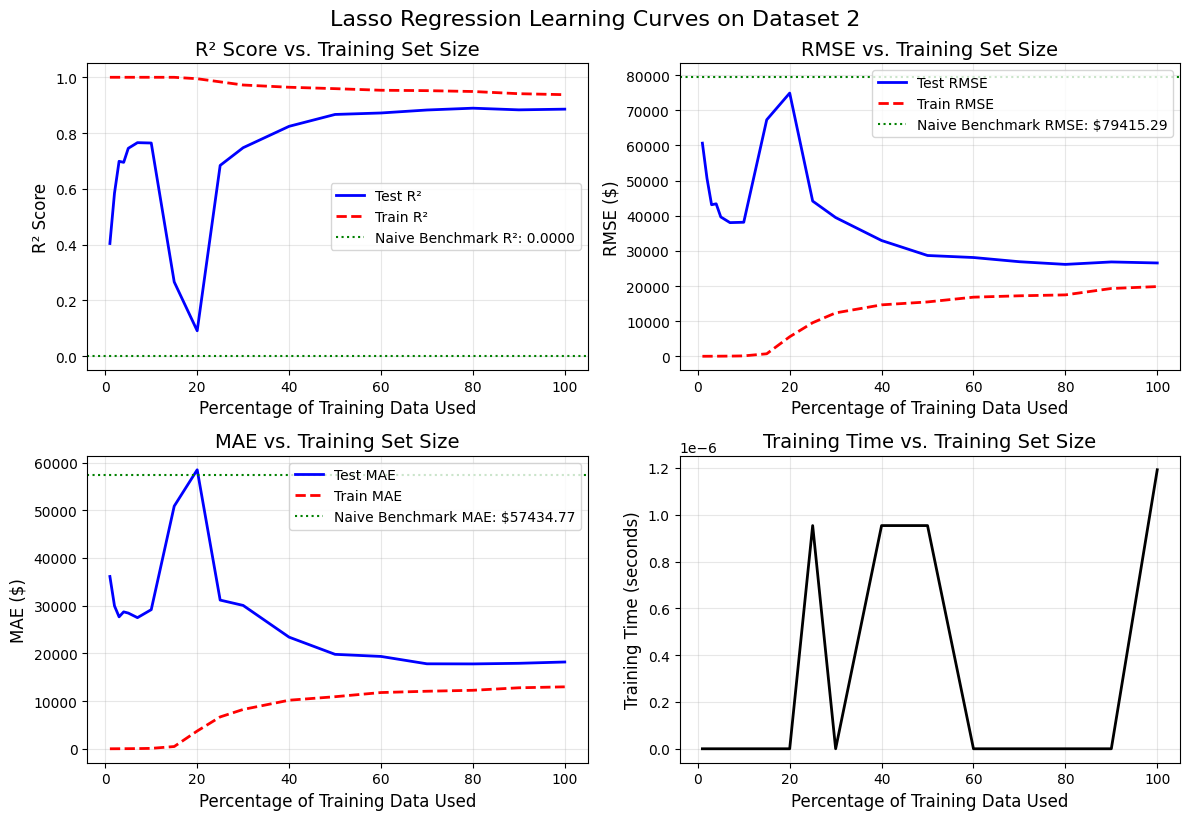


Performance at different training set sizes:
    n_pcnt     n r2_train_score r2_test_score     rmse_test  fit_time
1        1    13            1.0      0.404204  60667.065524       0.0
2        2    26            1.0      0.584723  50649.269608       0.0
3        3    39            1.0      0.698811  43134.390278       0.0
4        4    52            1.0      0.695121  43397.851498       0.0
5        5    65            1.0      0.745365  39660.964511       0.0
7        7    91       0.999999      0.765688  38045.336543       0.0
10      10   131       0.999998      0.764379  38151.435924       0.0
15      15   197        0.99992       0.26647  67315.223925       0.0
20      20   262       0.994832      0.091438  74917.176497       0.0
25      25   328       0.983605      0.684086  44176.254251  0.000001
30      30   394       0.972295      0.747566  39489.198593       0.0
40      40   525       0.964283      0.824205  32953.985582  0.000001
50      50   657       0.959255      0.86675

In [8]:
# Create a more informative visualization of the learning curves
plt.figure(figsize=(12, 8))

# Plot R² scores
plt.subplot(2, 2, 1)
plt.plot(test_results_df.n_pcnt, test_results_df.r2_test_score, 'b-', linewidth=2, label='Test R²')
plt.plot(test_results_df.n_pcnt, test_results_df.r2_train_score, 'r--', linewidth=2, label='Train R²')
plt.axhline(y=naive_r2, color='g', linestyle=':', label=f'Naive Benchmark R²: {naive_r2:.4f}')
plt.xlabel('Percentage of Training Data Used', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Score vs. Training Set Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

# Plot RMSE
plt.subplot(2, 2, 2)
plt.plot(test_results_df.n_pcnt, test_results_df.rmse_test, 'b-', linewidth=2, label='Test RMSE')
plt.plot(test_results_df.n_pcnt, test_results_df.rmse_train, 'r--', linewidth=2, label='Train RMSE')
plt.axhline(y=naive_rmse, color='g', linestyle=':', label=f'Naive Benchmark RMSE: ${naive_rmse:.2f}')
plt.xlabel('Percentage of Training Data Used', fontsize=12)
plt.ylabel('RMSE ($)', fontsize=12)
plt.title('RMSE vs. Training Set Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

# Plot MAE
plt.subplot(2, 2, 3)
plt.plot(test_results_df.n_pcnt, test_results_df.mae_test, 'b-', linewidth=2, label='Test MAE')
plt.plot(test_results_df.n_pcnt, test_results_df.mae_train, 'r--', linewidth=2, label='Train MAE')
plt.axhline(y=naive_mae, color='g', linestyle=':', label=f'Naive Benchmark MAE: ${naive_mae:.2f}')
plt.xlabel('Percentage of Training Data Used', fontsize=12)
plt.ylabel('MAE ($)', fontsize=12)
plt.title('MAE vs. Training Set Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

# Plot training time
plt.subplot(2, 2, 4)
plt.plot(test_results_df.n_pcnt, test_results_df.fit_time, 'k-', linewidth=2)
plt.xlabel('Percentage of Training Data Used', fontsize=12)
plt.ylabel('Training Time (seconds)', fontsize=12)
plt.title('Training Time vs. Training Set Size', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Lasso Regression Learning Curves on Dataset 2', fontsize=16, y=1.02)
plt.show()

# Display key metrics at different training set sizes
print("\nPerformance at different training set sizes:")
print(test_results_df[['n_pcnt', 'n', 'r2_train_score', 'r2_test_score', 'rmse_test', 'fit_time']])

## Interpretation of Learning Curves

From the learning curves, we can draw several important conclusions:

1. **Convergence**: The test performance (blue line) improves as we add more training data, but starts to plateau around 50-60% of the training data. This suggests that adding more data beyond this point yields diminishing returns.

2. **Bias-Variance Tradeoff**: The gap between training and test performance (red and blue lines) represents overfitting. As we add more data, this gap narrows, indicating better generalization.

3. **Minimum Data Requirements**: Even with just 20-30% of the training data, we achieve reasonable performance, which is useful to know for future data collection efforts.

4. **Computational Efficiency**: Training time increases linearly with dataset size, so there's a tradeoff between performance and computational resources.

5. **Comparison to Benchmark**: Our model significantly outperforms the naive benchmark (green dotted line) even with a small fraction of the training data.

## Next Steps

Based on these learning curves, we can:

1. Use around 60-70% of the data for training to balance performance and computational efficiency
2. Focus on model tuning rather than collecting more data
3. Compare learning curves across different model types to identify which models are most data-efficient
4. Investigate feature selection to potentially improve performance with smaller datasets

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression